In [ ]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 7.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons

In [ ]:
X, y = make_moons(
    n_samples=100,
    noise=0.25,
    random_state=3
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 2)
y shape: (100,)


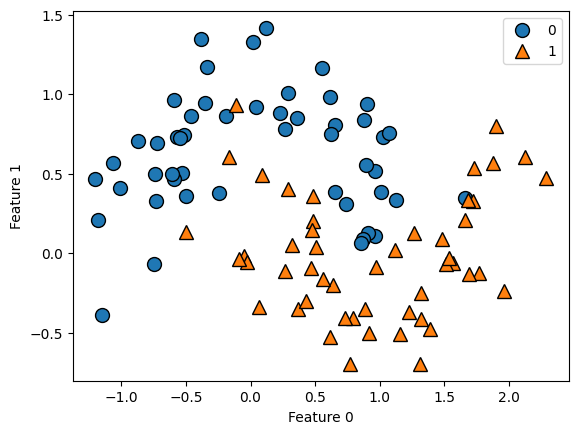

In [ ]:
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)

plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (75, 2)
X_test shape: (25, 2)


In [ ]:
mlp = MLPClassifier(
    solver='lbfgs',
    random_state=0
)

mlp.fit(X_train, y_train)

print("Training set score: {:.2f}".format(
    mlp.score(X_train, y_train)
))

print("Test set score: {:.2f}".format(
    mlp.score(X_test, y_test)
))

Training set score: 1.00
Test set score: 0.88


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


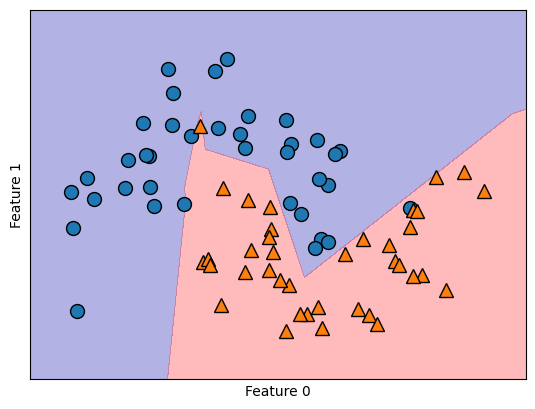

In [ ]:
mlp = MLPClassifier(
    solver='lbfgs',
    random_state=0,
    hidden_layer_sizes=[10]
)

mlp.fit(X_train, y_train)

mglearn.plots.plot_2d_separator(
    mlp,
    X_train,
    fill=True,
    alpha=.3
)

mglearn.discrete_scatter(
    X_train[:, 0],
    X_train[:, 1],
    y_train
)

plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


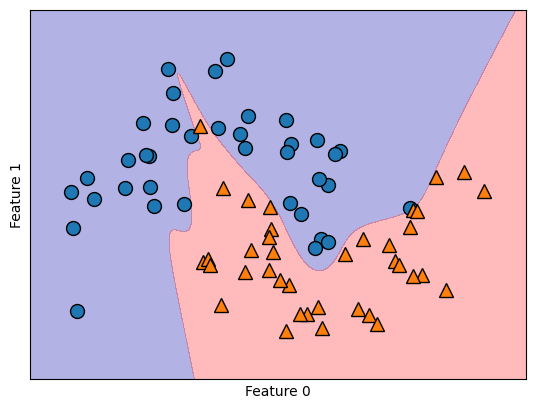

In [ ]:
mlp = MLPClassifier(
    solver='lbfgs',
    activation='tanh',
    random_state=0,
    hidden_layer_sizes=[10, 10]
)

mlp.fit(X_train, y_train)

mglearn.plots.plot_2d_separator(
    mlp,
    X_train,
    fill=True,
    alpha=.3
)

mglearn.discrete_scatter(
    X_train[:, 0],
    X_train[:, 1],
    y_train
)

plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


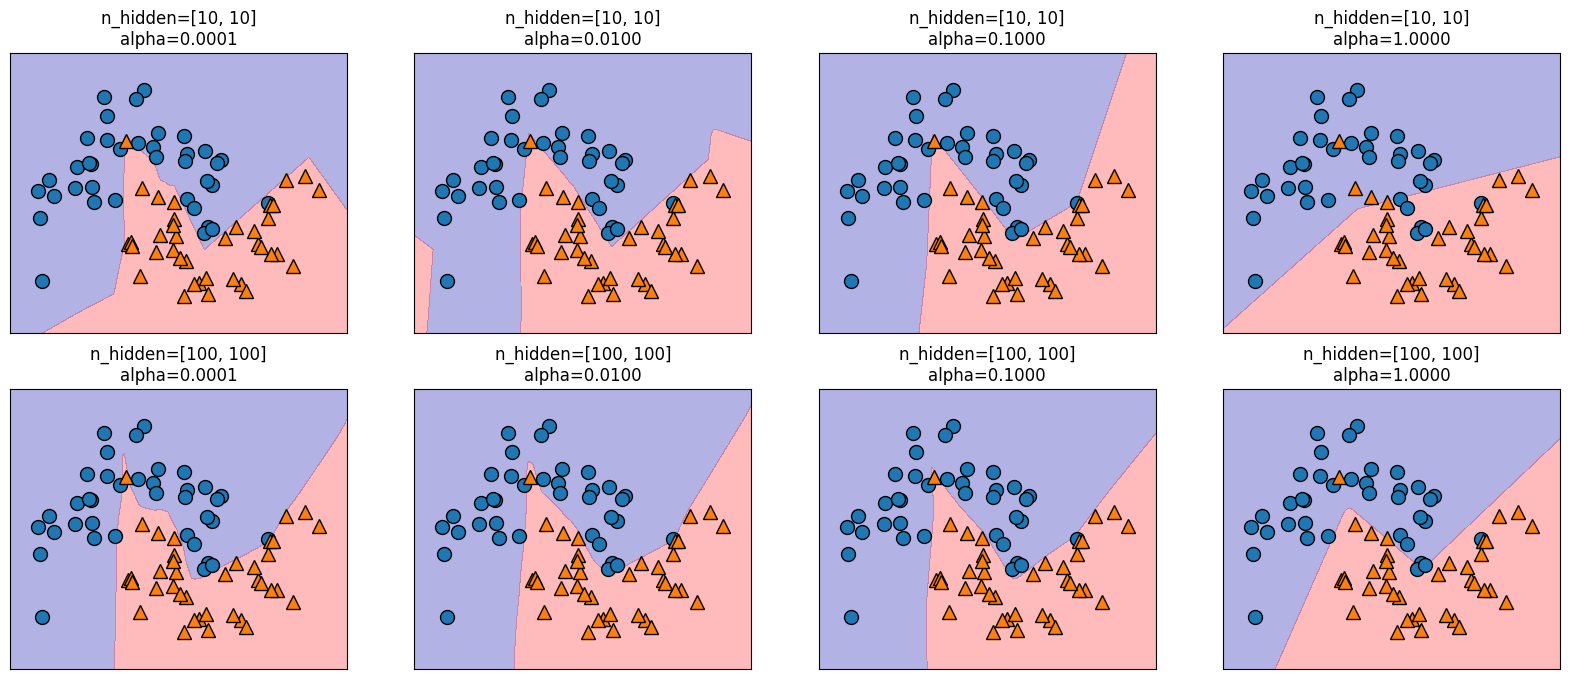

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for axx, n_hidden_nodes in zip(axes, [10, 100]):
    for ax, alpha in zip(
        axx,
        [0.0001, 0.01, 0.1, 1]
    ):
        mlp = MLPClassifier(
            solver='lbfgs',
            random_state=0,
            hidden_layer_sizes=[
                n_hidden_nodes,
                n_hidden_nodes
            ],
            alpha=alpha
        )

        mlp.fit(X_train, y_train)

        mglearn.plots.plot_2d_separator(
            mlp,
            X_train,
            fill=True,
            alpha=.3,
            ax=ax
        )

        mglearn.discrete_scatter(
            X_train[:, 0],
            X_train[:, 1],
            y_train,
            ax=ax
        )

        ax.set_title(
            "n_hidden=[{}, {}]\nalpha={:.4f}".format(
                n_hidden_nodes,
                n_hidden_nodes,
                alpha
            )
        )

plt.show()